# Imports

In [1]:
from pathlib import Path
import pypff
from matplotlib import pyplot as plt
import numpy as np

import heap

## Read Test Data

In [2]:
data_file = Path("../test_data/20260709/obs_Palomar.start_2026-07-09T08:35:09Z.runtype_obs-test.pffd/").resolve()
data_path = Path(data_file).resolve()
if not data_path.exists():
    raise FileNotFoundError(f"Data directory not found: {data_path}")
# else:
#     print(data_path)

In [3]:
# read ph1024 data file (Fern, preflip run)
file = str(data_path / "start_2026-07-09T08:35:53Z.dp_ph1024.bpp_2.module_252.seqno_0.pff")
pff = pypff.io.datapff(file)
data, metadata = pff.readpff(metadata=True)

In [4]:
data

array([[ 17,  23,  21, ..., -30,  -9, -10],
       [ 38,  29,  30, ...,   9,   2,  10],
       [ 39,  29,  11, ...,   8,  12, -12],
       ...,
       [ 35,  31,  31, ...,  10,   1,  11],
       [ 29,  31,   6, ..., -15,  -3,   6],
       [ 26,  30,  30, ...,  -4,   0,  12]], dtype=int16)

In [5]:
# How many events do we have?
len(data)

10131

In [6]:
# Check accessing single pixel for a single event
print(data[0][2])

21


## Plot the data

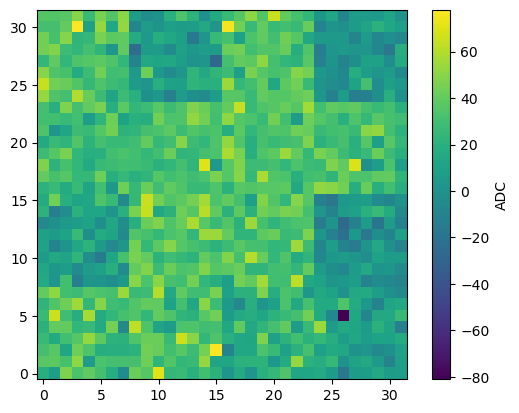

In [7]:
# get quabo_num from metadata, so that we know the packet is from which Quabo
#quabo_0 = metadata['quabo_0']

# Plot this event
skip = 4321

fig = plt.figure()
matrix = data[skip].reshape((32, 32))
plt.imshow(matrix, origin='lower')
plt.colorbar(label='ADC')
plt.show()

# Make Pedestals

### Now make pedestal distributions for all pixels and get mean and std

In [8]:
from heap.make_pedestals import calculate_pedestal_and_pedvar

pedestal, pedestal_variance = calculate_pedestal_and_pedvar(data)

### Plot pedestals

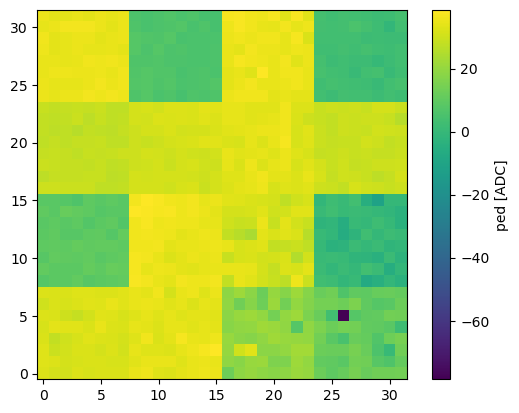

In [9]:
fig = plt.figure()
ped_image = pedestal.reshape((32, 32))
plt.imshow(ped_image, origin='lower')
plt.colorbar(label='ped [ADC]')
plt.show()

### Plot ped vars

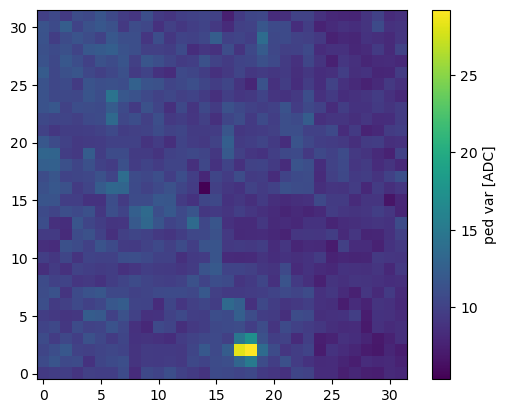

In [10]:
fig = plt.figure()
ped_var_image = pedestal_variance.reshape((32, 32))
plt.imshow(ped_var_image, origin='lower')
plt.colorbar(label='ped var [ADC]')